<a href="https://colab.research.google.com/github/IsaacFigNewton/CommitteeHearingDiscourseParser/blob/main/DH2024_DigitalDemocracy_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Accessing & working with the Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018


This notebook will act as a guide for a person with minimal knowledge of coding to make use of the files and retrieve useful information from the corpus.


The dataset can be downloaded directly from this website: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

This corpus is distributed under the cc-by-nc-sa-4.0 license. Please review before accessing. https://creativecommons.org/licenses/by-nc-sa/4.0/

Please cite as:

Khosmood, F., Dekhtyar, A., Ellwein, S., White, B., "The Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018", Digital Humanities, Washington, DC, August 2024.

# Download files

The Digital Democracy Corpus can be downloaded from here: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

The following code cell will downloaded the relevant files from the data repository and store them in the Colab runtime.

 Files in Colab runtime storage can be accessed by clicking on the folder button on the left sidebar. Double click on a file to view a preview of the file. Anything stored Colab runtime storage will disappear once the session is over. To save these files to your physical computer, right click on the file you'd like to save and click download.

In [1]:
from pathlib import Path
import subprocess
import zipfile
import os

#This is where the unzipped corpus file is stored
CORPUS_FILE_PATH = 'DH2024_Corpus_Release/'
corpus_dir = Path(CORPUS_FILE_PATH)
zip_path = Path("digitaldemocracy-2015-2018/DH2024_Corpus_Release.zip")
repo_dir = Path("digitaldemocracy-2015-2018")

# Clone repository if not present
if not repo_dir.is_dir():
    print("Corpus directory not found. Cloning repository...")
    subprocess.run(
        ["git", "clone", "https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018"],
        check=True,
    )
    print("Repository cloned successfully.")

# Extract zip file if corpus directory doesn't exist
if not corpus_dir.is_dir():
    if zip_path.exists():
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found!")
else:
    print(f"Corpus already extracted at {corpus_dir}")

Corpus already extracted at DH2024_Corpus_Release


# Read the relevant files into Python Objects by set

In [2]:
from src import HearingLoader, HearingParser

# Initialize the HearingLoader with the corpus path
loader = HearingLoader(corpus_path='DH2024_Corpus_Release/')

# Discussion Transcripts

In [3]:
# discussion will contain all the information from bill CA_201720180AB10 in hearing id 51835
# 'CA_201720180AB10': ['51835',
#   '52298',
#   '52708',
#   '52856',
#   '53960',
#   '54363',
#   '54505']
hearing = loader.bill_discussion_info(51835, "CA_201720180AB10")
vars(hearing)

{'hid': 51835,
 'bid': 'CA_201720180AB10',
 'cid': 546,
 'cname': 'Assembly Standing Committee on Education',
 'hearing_date': datetime.datetime(2017, 3, 15, 0, 0),
 'state': 'CA',
 'speakers': {113: Speaker(is_legislator=None, is_committee_member=None, is_bill_author=None, pid=113, first_name='Patrick', last_name="O'Donnell", speaker_position=None, speaker_role=None),
  112: Speaker(is_legislator=None, is_committee_member=None, is_bill_author=None, pid=112, first_name='Cristina', last_name='Garcia', speaker_position=None, speaker_role=None),
  103369: Speaker(is_legislator=None, is_committee_member=None, is_bill_author=None, pid=103369, first_name='Harold', last_name='Spikes', speaker_position=None, speaker_role=None),
  103371: Speaker(is_legislator=None, is_committee_member=None, is_bill_author=None, pid=103371, first_name='Kenneth', last_name='Vuylsteke', speaker_position=None, speaker_role=None),
  103374: Speaker(is_legislator=None, is_committee_member=None, is_bill_author=None, 

In [4]:
# Using pprint_hearing we layout the transcript in a human readable format
HearingLoader.pprint_hearing(hearing)


State:		CA
Committee:	Assembly Standing Committee on Education
Bill:		CA_201720180AB10
Date:		2017-03-15

Transcript:
Patrick O'Donnell:   She'll be presenting AB 10, file item number one.
Cristina Garcia:     Thank you. Good afternoon Chair and members. I'm here presenting AB 10 would require vital menstrual products, pads, and tampons to be provided in school, colleges, shelters throughout the state. Menstrual products are a basic necessity similar to toilet paper. As early as the fourth grade young girls get their period and may not be prepared nor understand the natural changes of their bodies many of these young girls end up missing school three to five days a month on a regular basis, because they lack basic access to these products. No young girl should ever have to miss school because she does not have access to these basic health needs. For some young girls, access to these products is an additional barrier to their education. It's also loss of funding for school due to absen

# Try loading all the hearings

In [5]:
hearings = loader.load_all_committee_hearings()
relevant_hearings = [h for h in hearings if h.bid != 'CA_NO BILL DISCUSSED']

invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'


In [9]:
print(len(hearings))
print(len(relevant_hearings))

8218
7069


In [10]:
hearing_parser = HearingParser()

In [13]:
from src import build_utterance_rows

utterances_df = build_utterance_rows(relevant_hearings)

In [17]:
utterances_df.head(500).to_csv('utterances_sample.csv')

In [18]:
import pandas as pd

labeled_utterances_df = pd.read_csv('./utterances_sample_labeled.csv')

In [23]:
labeled_utterances_df.head()

,Unnamed: 0,hid,bid,state,uid,pid,text,prev_text,next_text,context_text,...,word_count,has_bill_id,has_bill_action,has_presentation_cue,has_motion_cue,has_vote_cue,has_disposition_cue,aye_count,no_count,stage_label
0,0,52054,CA_201720180AB92,CA,0,165448,"Welcome, Mr. Bonta.",,"Thank you, I feel welcome.","PREV: CURR: Welcome, Mr. Bonta. NEXT: Thank y...",...,3,0,0,0,0,0,0,0,0,bill_focus_or_presentation
1,1,52054,CA_201720180AB92,CA,1,85,"Thank you, I feel welcome.","Welcome, Mr. Bonta.","And I know you were here earlier, and we appre...","PREV: Welcome, Mr. Bonta. CURR: Thank you, I f...",...,5,0,0,0,0,0,0,0,0,bill_focus_or_presentation
2,2,52054,CA_201720180AB92,CA,2,165448,"And I know you were here earlier, and we appre...","Thank you, I feel welcome.",Thank you for encouraging them. Good to see yo...,"PREV: Thank you, I feel welcome. CURR: And I k...",...,18,0,0,0,0,0,0,0,0,bill_focus_or_presentation
3,3,52054,CA_201720180AB92,CA,3,85,Thank you for encouraging them. Good to see yo...,"And I know you were here earlier, and we appre...","Thank you very much, if witnesses would like t...","PREV: And I know you were here earlier, and we...",...,110,1,0,0,0,1,0,1,1,vote
4,4,52054,CA_201720180AB92,CA,4,165448,"Thank you very much, if witnesses would like t...",Thank you for encouraging them. Good to see yo...,"Madam Chair, members. Eddie Bernacchi, on beha...",PREV: Thank you for encouraging them. Good to ...,...,15,0,0,0,0,0,0,0,0,public_testimony


In [20]:
labeled_utterances_df['stage_label'].value_counts()

stage_label
bill_focus_or_presentation    192
public_testimony              168
vote                           69
motion                         35
pre_bill                       18
disposition                    18
Name: count, dtype: int64

In [21]:
text_cols = [
  'text',
  'prev_text',
  'next_text',
  'context_text',
]

for col in text_cols:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna('')

labeled_utterances_df['stage_label'] = labeled_utterances_df['stage_label'].fillna('unknown')

In [25]:
from sklearn.model_selection import GroupShuffleSplit

groups = labeled_utterances_df['bid']

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42,
)

train_idx, test_idx = next(
    splitter.split(labeled_utterances_df, labeled_utterances_df['stage_label'], groups)
)

train_df = labeled_utterances_df.iloc[train_idx].copy()
test_df = labeled_utterances_df.iloc[test_idx].copy()

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))

Train rows: 310
Test rows: 190


In [26]:
text_feature = 'context_text'

categorical_features = [
  'speaker_position',
  'prev_speaker_position',
  'next_speaker_position',
]

numeric_features = [
  'is_legislator',
  'is_committee_member',
  'relative_position',
  'word_count',
  'has_bill_id',
  'has_bill_action',
  'has_presentation_cue',
  'has_motion_cue',
  'has_vote_cue',
  'has_disposition_cue',
  'aye_count',
  'no_count',
]

In [27]:
for col in numeric_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna(0)
  train_df[col] = train_df[col].fillna(0)
  test_df[col] = test_df[col].fillna(0)

for col in categorical_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna('unknown')
  train_df[col] = train_df[col].fillna('unknown')
  test_df[col] = test_df[col].fillna('unknown')

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


model = Pipeline([
  ('features', ColumnTransformer([
    ('text', TfidfVectorizer(
      ngram_range=(1, 2),
      min_df=1,
      max_features=20000,
    ), text_feature),

    ('categorical', OneHotEncoder(
      handle_unknown='ignore',
    ), categorical_features),

    ('numeric', StandardScaler(), numeric_features),
  ])),

  ('classifier', LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs',
  )),
])

In [30]:
feature_cols = [text_feature] + categorical_features + numeric_features

X_train = train_df[feature_cols]
y_train = train_df['stage_label']

X_test = test_df[feature_cols]
y_test = test_df['stage_label']

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['bill_focus_or_presentation','disposition','motion','pre_bill', 'public_testimony','vote']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['context_text','speaker_position','prev_speaker_position',..., 'has_disposition_cue','aye_count','no_count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed a

In [31]:
from sklearn.metrics import classification_report

pred = model.predict(X_test)

print(classification_report(
    y_test,
    pred,
    digits=3,
))

                            precision    recall  f1-score   support

bill_focus_or_presentation      0.883     0.757     0.815        70
               disposition      0.400     0.667     0.500         6
                    motion      0.800     0.727     0.762        11
                  pre_bill      1.000     0.667     0.800         6
          public_testimony      0.845     0.922     0.882        77
                      vote      0.909     1.000     0.952        20

                  accuracy                          0.842       190
                 macro avg      0.806     0.790     0.785       190
              weighted avg      0.854     0.842     0.843       190



Matplotlib is building the font cache; this may take a moment.


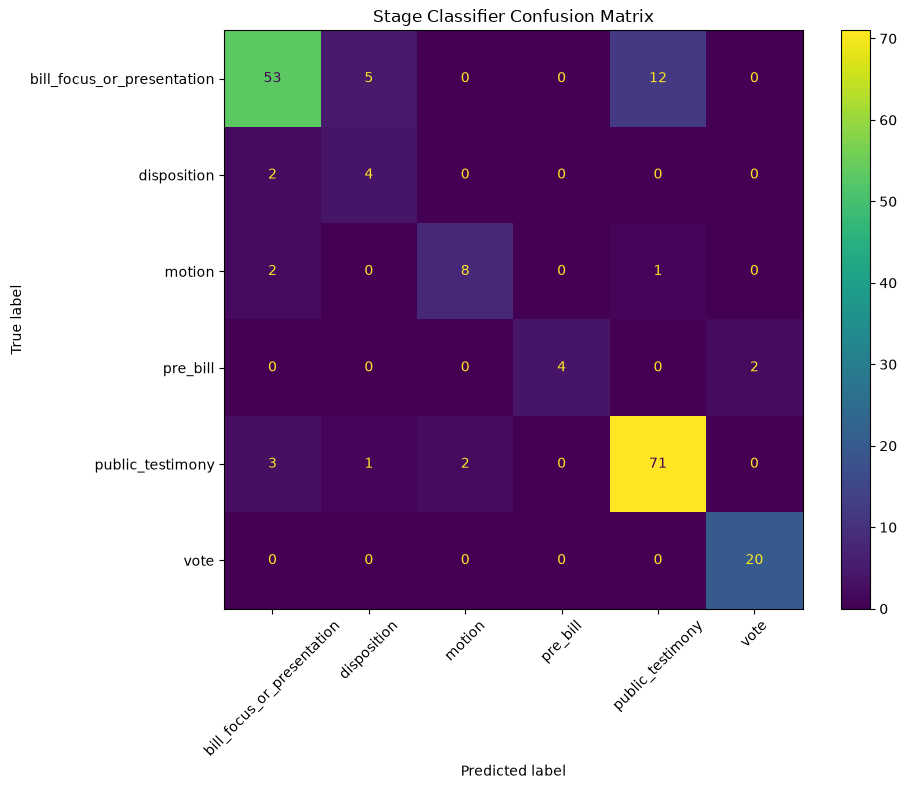

In [78]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay


labels = sorted(y_test.unique())

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    labels=labels,
    xticks_rotation=45,
    ax=ax,
)

ax.set_title('Stage Classifier Confusion Matrix')
plt.tight_layout()
plt.show()

In [33]:
def smooth_label_list(labels):
  labels = list(labels)

  for i in range(1, len(labels) - 1):
    prev_label = labels[i - 1]
    curr_label = labels[i]
    next_label = labels[i + 1]

    if prev_label == next_label and curr_label != prev_label:
        labels[i] = prev_label

  return labels

def predict_label_list_for_hearing(
  hearing,
  utterances_df,
  model,
  feature_cols,
  smooth=True,
):
  hearing_df = utterances_df[
    (utterances_df['hid'] == hearing.hid)
    & (utterances_df['bid'].astype(str) == str(hearing.bid))
  ].copy()

  if hearing_df.empty:
    raise ValueError(
      f'No rows found for hid={hearing.hid}, bid={hearing.bid}'
    )

  hearing_df = hearing_df.sort_values('uid').copy()

  X = hearing_df[feature_cols]

  labels = list(model.predict(X))

  if smooth:
    labels = smooth_label_list(labels)

  return labels

In [38]:
labels = predict_label_list_for_hearing(
    hearing=relevant_hearings[0],
    utterances_df=utterances_df,
    model=model,
    feature_cols=feature_cols,
    smooth=True,
)

print(labels)

['bill_focus_or_presentation', 'bill_focus_or_presentation', 'bill_focus_or_presentation', 'bill_focus_or_presentation', 'bill_focus_or_presentation', 'public_testimony', 'public_testimony', 'public_testimony', 'bill_focus_or_presentation', 'bill_focus_or_presentation', 'bill_focus_or_presentation', 'bill_focus_or_presentation', 'vote', 'disposition', 'disposition', 'disposition', 'bill_focus_or_presentation', 'bill_focus_or_presentation']


In [47]:
special_hearing = None
for h in relevant_hearings:
  if h.bid == 'CA_201720180AB2721':
    special_hearing = h
    break

In [44]:
standard_example = relevant_hearings[0]

Note: special case of Chairman presenting to someone else: Bill ID CA_201720180SB1293

Special kind of bill discussion: CA_201720180AB1708
Case where you have to use handoff cue: CA_201720180AB2721
CA_201720180SCR159

In [55]:
def pprint_hearing_labels(hearing):
  
  labels = predict_label_list_for_hearing(
    hearing=relevant_hearings[0],
    utterances_df=utterances_df,
    model=model,
    feature_cols=feature_cols,
    smooth=True,
  )

  """Print formatted transcript with labels."""
  print()
  print(f"State:\t\t{hearing.state}")
  print(f"Committee:\t{hearing.cname}")
  print(f"Bill:\t\t{hearing.bid}")
  print(f"Date:\t\t{hearing.hearing_date.strftime('%Y-%m-%d')}")
  print()
  print("Transcript:")
  for i, contribution in enumerate(hearing.utterances):
    speaker = hearing.speakers[contribution.pid]
    print(f'[{labels[i] if i < len(labels) else 'UNKNOWN'}]')
    first_name = speaker.first_name or "UNKNOWN"
    last_name = speaker.last_name or "UNKNOWN"
    name = f"{first_name} {last_name}:"
    print(f"{name:<20} {contribution.text}")
  print()

In [84]:
standard_example_2 = relevant_hearings[17]

In [96]:
HearingLoader.pprint_hearing(standard_example)


State:		CA
Committee:	Assembly Standing Committee on Accountability and Administrative Review
Bill:		CA_201720180AB92
Date:		2017-03-22

Transcript:
Susan Eggman:        Welcome, Mr. Bonta.
Rob Bonta:           Thank you, I feel welcome.
Susan Eggman:        And I know you were here earlier, and we appreciate your getting your steps in by coming back.
Rob Bonta:           Thank you for encouraging them. Good to see you, good morning. I know in the last bill here, I'm very pleased to have the opportunity to present AB 92. Thank you. AB 92 will extend the sunset clause on the current 5% retention cap statute pertaining to public works projects from January 1, 2018 to January 1, 2023. This is a vital policy for the construction industry especially for small and emerging construction businesses. I think you have seen this policy before it's worked well in action and I think it deserves a five year additional extension and there's no opposition. Respectfully ask for your aye vote.
Susan Eg

In [97]:
pprint_hearing_labels(standard_example)


State:		CA
Committee:	Assembly Standing Committee on Accountability and Administrative Review
Bill:		CA_201720180AB92
Date:		2017-03-22

Transcript:
[bill_focus_or_presentation]
Susan Eggman:        Welcome, Mr. Bonta.
[bill_focus_or_presentation]
Rob Bonta:           Thank you, I feel welcome.
[bill_focus_or_presentation]
Susan Eggman:        And I know you were here earlier, and we appreciate your getting your steps in by coming back.
[bill_focus_or_presentation]
Rob Bonta:           Thank you for encouraging them. Good to see you, good morning. I know in the last bill here, I'm very pleased to have the opportunity to present AB 92. Thank you. AB 92 will extend the sunset clause on the current 5% retention cap statute pertaining to public works projects from January 1, 2018 to January 1, 2023. This is a vital policy for the construction industry especially for small and emerging construction businesses. I think you have seen this policy before it's worked well in action and I think 

In [37]:
len(relevant_hearings[1].utterances)

33

In [34]:
hearing_parser._detect_first_presentation_utterance(relevant_hearings[9])

0

In [92]:
relevant_hearings[4].bid

'CA_201720180AB677'

In [ ]:
from sklearn import